# Assignment - Linear Regression on the Medical Cost Personal Dataset (Kaggle)

Predicting Medical Insurance Cost Using Linear Regression
Objective

Insurance companies want to estimate how much a patient's medical expenses will cost based on their personal information.

Target Variable

Charges (Medical Insurance Cost)

Features

Age
BMI
Number of Children
Sex
Smoker
Region


#### Import libraries


In [35]:
# Import pandas for working with DataFrames
import pandas as pd

# Import numpy
import numpy as np

# Import matplotlib for visualization
import matplotlib.pyplot as plt

# Import Linear Regression
from sklearn.linear_model import LinearRegression

# Import train-test split
from sklearn.model_selection import train_test_split

# Import evaluation metrics
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score


#### Load the dataset


In [36]:
df = pd.read_csv("insurance.csv")

print(f"Shape: {df.shape}")



Shape: (1338, 7)


#### View Dataset


In [37]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [38]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


#### Statistical Summary

In [59]:
# Summary statistics (numeric + categorical)
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


#### check for missing values

In [40]:
# Missing values per column
df.isnull().sum()


age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [41]:
# Duplicate rows
print(f"Duplicate rows: {df.duplicated().sum()}")
df[df.duplicated(keep=False)]


Duplicate rows: 1


,age,sex,bmi,children,smoker,region,charges
195,19,male,30.59,0,no,northwest,1639.5631
581,19,male,30.59,0,no,northwest,1639.5631


#### Convert Categorical Variables

Linear Regression only accepts numbers.

Convert:
Male/Female
Yes/No
Regions

In [42]:
df = pd.get_dummies(df, drop_first=True)

#### Select Features

In [43]:
X = df.drop("charges", axis=1)

#### Select Target Variable

In [44]:
y = df["charges"]

#### Split Dataset

In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

#### create model

In [46]:
model = LinearRegression()

#### Train the Model

In [47]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](8,)","[ 256.98, 337.09, 425.28,...,-370.68,-657.86,-809.8 ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](8,)","['age','bmi','children',...,'region_northwest','region_southeast', 'region_southwest']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.193e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,8


#### Make Predictions

In [48]:
predictions = model.predict(X_test)

#### Compare Actual vs Predicted

In [49]:
results = pd.DataFrame({
    "Actual Charges": y_test,
    "Predicted Charges": predictions
})

results.head(10)

,Actual Charges,Predicted Charges
764,9095.06825,8969.550274
887,5272.17580,7068.747443
890,29330.98315,36858.410912
1293,9301.89355,9454.678501
259,33750.29180,26973.173457
1312,4536.25900,10864.113164
899,2117.33885,170.280841
752,14210.53595,16903.450287
1286,3732.62510,1092.430936
707,10264.44210,11218.343184


#### Evaluate the model
Mean absolute error (MAE)

In [50]:
mae = mean_absolute_error(y_test, predictions)

print("Mean Absolute Error:", mae)

Mean Absolute Error: 4181.1944737536505


Mean Squared Error

In [51]:
mse = mean_squared_error(y_test, predictions)

print("Mean Squared Error:", mse)

Mean Squared Error: 33596915.85136146


R² Score

In [52]:
r2 = r2_score(y_test, predictions)

print("R² Score:", r2)

R² Score: 0.7835929767120723


#### visualise predictions

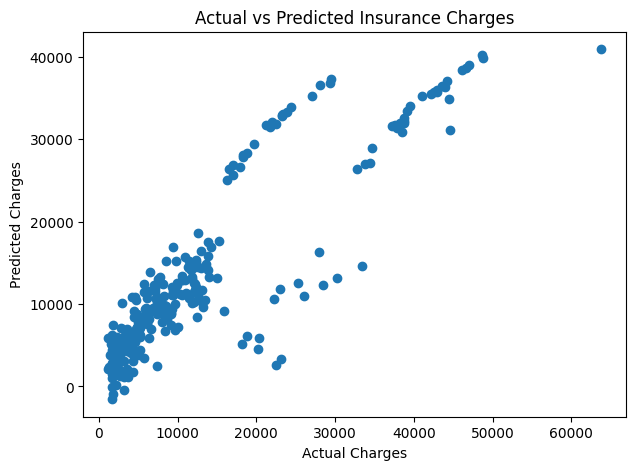

In [53]:
plt.figure(figsize=(7,5))

plt.scatter(y_test, predictions)

plt.xlabel("Actual Charges")

plt.ylabel("Predicted Charges")

plt.title("Actual vs Predicted Insurance Charges")

plt.show()

Predict for a New Patient

Suppose a new patient has:

Age = 45
BMI = 28
Children = 2
Male
Smoker = Yes
Region = Southeast

Since we used one-hot encoding (drop_first=True), the input DataFrame must have the same columns as X.

In [54]:
new_patient = pd.DataFrame({
    'age': [45],
    'bmi': [28],
    'children': [2],
    'sex_male': [1],
    'smoker_yes': [1],
    'region_northwest': [0],
    'region_southeast': [1],
    'region_southwest': [0]
})

Predict the insurance cost:

In [55]:
predicted_charge = model.predict(new_patient)

print("Predicted Medical Cost:", predicted_charge[0])

Predicted Medical Cost: 32896.50960124701


Step 18: Understanding What the Model Learned

Display the coefficients.

In [56]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print(coefficients)

            Feature   Coefficient
0               age    256.975706
1               bmi    337.092552
2          children    425.278784
3          sex_male    -18.591692
4        smoker_yes  23651.128856
5  region_northwest   -370.677326
6  region_southeast   -657.864297
7  region_southwest   -809.799354


#### Interpretation
Positive coefficient (+): As the feature increases, the predicted insurance cost increases.
Negative coefficient (−): As the feature increases, the predicted insurance cost decreases.
Larger absolute values: The feature has a stronger influence on the prediction.

For example, you'll typically observe:

smoker_yes has the largest positive coefficient, indicating smokers generally incur much higher medical costs.
age usually has a positive coefficient, as older individuals tend to have higher healthcare expenses.
bmi often has a positive effect, though smaller than smoking.
The regional variables generally have a relatively minor impact.

## 8. Conclusion

- The dataset ([Kaggle: Medical Cost Personal Datasets](https://www.kaggle.com/datasets/mirichoi0218/insurance))
  needed light cleaning: one duplicate row removed, categorical variables one-hot encoded.
- **Smoking status is by far the strongest predictor** of medical insurance charges, followed by
  age and BMI — consistent with established health-economics research.
- The linear model achieves a solid R² on the test set, but under-predicts the most expensive
  patients, reflecting the right-skewed nature of healthcare cost data.

**Possible next steps:** log-transform `charges` to reduce skew, add an explicit `bmi × smoker`
interaction term (since high BMI matters much more for smokers), or try a non-linear model (e.g.
Random Forest, Gradient Boosting) to better capture that interaction.
